# 05 — Part 2: Qwen Semantic Feature Pipeline
**IS5126 LLM-Enhanced Credit Risk Assessment — NUS**

This notebook covers **Part 2, Pipeline C** on a 3,000-loan stratified sample:

| Pipeline | Description |
|---------|-------------|
| **A'** | Traditional ML baseline on 3K sample (reference) |
| **B'** | Naive BERT features on 3K sample (reference) |
| **C**  | Qwen3-Max risk score from desc → added as ML feature |

**Output:** Table 2 — comparison of Baseline vs BERT vs Qwen on 3K sample

**Expected conclusion:** Qwen > BERT > Baseline, demonstrating that stronger LLMs extract more predictive semantic signals.

## 0. Setup

In [ ]:
!pip install -q transformers accelerate tqdm openai xgboost lightgbm shap

In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tqdm.auto import tqdm

import torch
from transformers import BertTokenizer, BertModel
from openai import OpenAI

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, balanced_accuracy_score,
    f1_score, precision_score, recall_score
)
import xgboost as xgb

warnings.filterwarnings('ignore')

COLORS = {
    'neutral': '#6C757D', 'bert': '#9B59B6',
    'qwen': '#E74C3C', 'xgb': '#2E86AB',
}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [ ]:
from google.colab import drive, userdata
drive.mount('/content/drive')

DRIVE_DIR  = '/content/drive/MyDrive/is5126'
DATA_DIR   = f'{DRIVE_DIR}/data/processed'
MODEL_DIR  = f'{DRIVE_DIR}/models'

RANDOM_STATE   = 42
TARGET_COL     = 'default'
SAMPLE_N       = 3000
BERT_PCA_N     = 50
BERT_MAX_LEN   = 128
BERT_BATCH     = 64
QWEN_MODEL     = 'qwen3-max'
QWEN_DELAY     = 0.5    # seconds between API calls

SAMPLE_3000_PATH = f'{DATA_DIR}/sample_3000.parquet'
BERT_EMBED_3000  = f'{DATA_DIR}/bert_embeddings_3000.npy'
BERT_INDEX_3000  = f'{DATA_DIR}/bert_embeddings_3000_index.npy'
QWEN_CACHE_PATH  = f'{MODEL_DIR}/qwen_cache_3000.json'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Sample 3,000 from Desc Subset

In [ ]:
if os.path.exists(SAMPLE_3000_PATH):
    print('Loading cached 3K sample...')
    df_sample = pd.read_parquet(SAMPLE_3000_PATH)
else:
    df_desc = pd.read_parquet(f'{DATA_DIR}/desc_subset.parquet')
    # Stratified sample by default label
    df_sample = df_desc.groupby(TARGET_COL, group_keys=False).apply(
        lambda x: x.sample(
            n=int(SAMPLE_N * len(x) / len(df_desc)),
            random_state=RANDOM_STATE
        )
    ).reset_index(drop=True)
    # Top up to exactly SAMPLE_N if rounding shortfall
    if len(df_sample) < SAMPLE_N:
        extra = df_desc[~df_desc.index.isin(df_sample.index)].sample(
            SAMPLE_N - len(df_sample), random_state=RANDOM_STATE
        )
        df_sample = pd.concat([df_sample, extra]).reset_index(drop=True)
    df_sample.to_parquet(SAMPLE_3000_PATH, index=False)
    print(f'Saved 3K sample.')

print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample[TARGET_COL].mean()*100:.2f}%')

Loading cached 3K sample...
Sample shape: (3000, 156)
Default rate: 15.30%


## 2. Feature Engineering & Train/Test Split

In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/is5126/src')
try:
    from features import create_derived_features
except ImportError:
    def create_derived_features(df):
        df = df.copy()
        df['monthly_inc'] = df['annual_inc'] / 12
        df['installment_to_income'] = df['installment'] / (df['monthly_inc'] + 1)
        df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
        if 'tot_cur_bal' in df.columns:
            df['revol_to_total_bal'] = df['revol_bal'] / (df['tot_cur_bal'] + 1)
            df['avg_account_bal'] = df['tot_cur_bal'] / (df['total_acc'] + 1)
        df['delinq_per_year'] = df['delinq_2yrs'] / (df['credit_history_months'] / 12 + 1)
        df['inq_per_open_acc'] = df['inq_last_6mths'] / (df['open_acc'] + 1)
        df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
        if 'acc_open_past_24mths' in df.columns:
            df['new_acc_rate'] = df['acc_open_past_24mths'] / (df['total_acc'] + 1)
        df['is_long_term'] = (df['term'] == 60).astype(int)
        return df

df_sample = create_derived_features(df_sample)

with open(f'{DATA_DIR}/woe_maps.json') as f:
    woe_maps = json.load(f)
with open(f'{DATA_DIR}/feature_metadata.json') as f:
    feat_meta = json.load(f)

WOE_CATS = ['home_ownership', 'verification_status', 'purpose',
            'initial_list_status', 'application_type', 'addr_state']
for feat in WOE_CATS:
    if feat in df_sample.columns and feat in woe_maps:
        wm = {k: float(v) for k, v in woe_maps[feat].items()}
        df_sample[f'{feat}_woe'] = df_sample[feat].astype(str).map(wm).fillna(0.0)

grade_related = feat_meta.get('grade_related', ['grade_num', 'sub_grade_num', 'int_rate'])
feature_cols = [c for c in feat_meta['feature_cols']
                if c not in grade_related and c in df_sample.columns]

df_train, df_test = train_test_split(
    df_sample, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df_sample[TARGET_COL]
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

X_train = df_train[feature_cols].fillna(0)
X_test  = df_test[feature_cols].fillna(0)
y_train = df_train[TARGET_COL]
y_test  = df_test[TARGET_COL]
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train: {len(df_train)} | Test: {len(df_test)} | Features: {len(feature_cols)}')

Train: 2400 | Test: 600 | Features: 65


In [ ]:
def calc_ks(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(max(tpr - fpr))

def evaluate_full(y_true, y_prob, name='Model'):
    auc  = roc_auc_score(y_true, y_prob)
    ks   = calc_ks(y_true, y_prob)
    gini = 2 * auc - 1
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thr = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= thr).astype(int)
    return {
        'Model':     name,
        'AUC':       round(auc, 4),
        'KS':        round(ks, 4),
        'Gini':      round(gini, 4),
        'BACC':      round(balanced_accuracy_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

XGB_KWARGS = dict(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='auc', early_stopping_rounds=30, verbosity=0
)

## 3. Pipeline A' — Traditional ML Baseline on 3K

In [ ]:
xgb_a = xgb.XGBClassifier(**XGB_KWARGS)
xgb_a.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
prob_a = xgb_a.predict_proba(X_test)[:, 1]
metrics_a = evaluate_full(y_test, prob_a, name="A': Traditional (3K)")
print(f'Pipeline A\': AUC={metrics_a["AUC"]} | KS={metrics_a["KS"]} | BACC={metrics_a["BACC"]}')

Pipeline A': AUC=0.6487 | KS=0.2355 | BACC=0.6178


## 4. Pipeline B' — BERT Features on 3K

In [ ]:
def extract_bert_embeddings(texts, model, tokenizer, batch_size=64, max_length=128, device='cpu'):
    model.eval()
    all_emb = []
    for i in tqdm(range(0, len(texts), batch_size), desc='BERT'):
        enc = tokenizer(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_emb)

In [ ]:
if os.path.exists(BERT_EMBED_3000):
    print('Loading cached BERT embeddings for 3K...')
    emb_all = np.load(BERT_EMBED_3000)
    idx_all = np.load(BERT_INDEX_3000)
else:
    # Check if we can reuse the 200K cache from notebook 04
    BERT_EMBED_200K = f'{DATA_DIR}/bert_embeddings.npy'
    BERT_INDEX_200K = f'{DATA_DIR}/bert_embeddings_index.npy'

    if os.path.exists(BERT_EMBED_200K):
        print('Slicing from 200K BERT cache...')
        emb_full = np.load(BERT_EMBED_200K)
        idx_full = np.load(BERT_INDEX_200K)
        id_to_row = {idx: i for i, idx in enumerate(idx_full)}
        sample_rows = [id_to_row[i] for i in df_sample.index if i in id_to_row]
        emb_all = emb_full[sample_rows]
        idx_all = np.array(list(df_sample.index[: len(sample_rows)]))
    else:
        print('Computing BERT for 3K...')
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        bert_m = BertModel.from_pretrained('bert-base-uncased').to(DEVICE)
        texts = df_sample['desc'].fillna('').tolist()
        emb_all = extract_bert_embeddings(texts, bert_m, tokenizer,
                                          BERT_BATCH, BERT_MAX_LEN, DEVICE)
        idx_all = df_sample.index.to_numpy()
        del bert_m; torch.cuda.empty_cache()

    np.save(BERT_EMBED_3000, emb_all)
    np.save(BERT_INDEX_3000, idx_all)
    print(f'Saved: {emb_all.shape}')

Loading cached BERT embeddings for 3K...


In [ ]:
id_to_row = {idx: i for i, idx in enumerate(idx_all)}
train_rows = [id_to_row[i] for i in df_train.index]
test_rows  = [id_to_row[i] for i in df_test.index]

# Try loading PCA from notebook 04; if not available, fit fresh
pca_path = f'{MODEL_DIR}/bert_pca.joblib'
if os.path.exists(pca_path):
    pca = joblib.load(pca_path)
    bert_train_pca = pca.transform(emb_all[train_rows])
    bert_test_pca  = pca.transform(emb_all[test_rows])
    print('Using PCA from notebook 04.')
else:
    pca = PCA(n_components=BERT_PCA_N, random_state=RANDOM_STATE)
    bert_train_pca = pca.fit_transform(emb_all[train_rows])
    bert_test_pca  = pca.transform(emb_all[test_rows])
    print('Fit fresh PCA on 3K train split.')

bert_cols = [f'bert_pc_{i}' for i in range(BERT_PCA_N)]
X_train_b = pd.concat([
    X_train.reset_index(drop=True),
    pd.DataFrame(bert_train_pca, columns=bert_cols)
], axis=1)
X_test_b = pd.concat([
    X_test.reset_index(drop=True),
    pd.DataFrame(bert_test_pca, columns=bert_cols)
], axis=1)

xgb_b = xgb.XGBClassifier(**XGB_KWARGS)
xgb_b.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=False)
prob_b = xgb_b.predict_proba(X_test_b)[:, 1]
metrics_b = evaluate_full(y_test, prob_b, name="B': + Naive BERT (3K)")
print(f'Pipeline B\': AUC={metrics_b["AUC"]} | KS={metrics_b["KS"]} | BACC={metrics_b["BACC"]}')

Using PCA from notebook 04.
Pipeline B': AUC=0.6599 | KS=0.2767 | BACC=0.6384


## 5. Pipeline C — Qwen3 Risk Score

Qwen3-Max API calls were run **offline** via `scripts/run_qwen_3000.py`.
We load the cached JSON here — **no API calls in this notebook**.

The script prompted Qwen with the `desc` text and returned structured JSON:
`{default_probability, risk_level, key_risk_factors, key_protective_factors, reasoning}`


In [ ]:
import re

def strip_think_tags(content: str) -> str:
    """Strip <think>...</think> chain-of-thought emitted by Qwen3-Max."""
    match = re.search(r'</think>\s*(.*)', content, re.DOTALL)
    return match.group(1).strip() if match else content.strip()

def parse_qwen_response(content: str) -> dict:
    """Parse Qwen JSON response into a dict with score and reasoning."""
    content = strip_think_tags(content)
    md_match = re.search(r'```(?:json)?\s*(.*?)```', content, re.DOTALL)
    if md_match:
        content = md_match.group(1).strip()
    try:
        parsed = json.loads(content)
        score = float(parsed.get('default_probability', -1))
        score = max(0.0, min(1.0, score))
        return {
            'score': score,
            'risk_level': parsed.get('risk_level', ''),
            'key_risk_factors': parsed.get('key_risk_factors', []),
            'key_protective_factors': parsed.get('key_protective_factors', []),
            'reasoning': parsed.get('reasoning', ''),
            'parse_error': False,
        }
    except (json.JSONDecodeError, ValueError, TypeError):
        float_match = re.search(r'\b(0\.\d+|1\.0)\b', content)
        score = float(float_match.group(1)) if float_match else float('nan')
        return {'score': score, 'raw_response': content[:200], 'parse_error': True}

print('Helpers ready: strip_think_tags, parse_qwen_response')


Helpers ready: strip_think_tags, parse_qwen_response


In [ ]:
# Load Qwen cache (produced by scripts/run_qwen_3000.py)
if not os.path.exists(QWEN_CACHE_PATH):
    raise FileNotFoundError(
        f'Qwen cache not found: {QWEN_CACHE_PATH}\n'
        'Run scripts/run_qwen_3000.py first, then upload the JSON to Drive.'
    )

with open(QWEN_CACHE_PATH) as f:
    qwen_cache = json.load(f)

df_sample['qwen_score'] = [
    qwen_cache.get(str(i), {}).get('score', float('nan'))
    for i in df_sample.index
]
df_sample['qwen_reasoning'] = [
    qwen_cache.get(str(i), {}).get('reasoning', '')
    for i in df_sample.index
]
df_sample['qwen_risk_level'] = [
    qwen_cache.get(str(i), {}).get('risk_level', '')
    for i in df_sample.index
]

valid = df_sample['qwen_score'].notna().sum()
parse_errors = sum(1 for v in qwen_cache.values() if v.get('parse_error', False))
print(f'Cache: {len(qwen_cache)} entries | valid={valid} | parse_errors={parse_errors}')
print(df_sample['qwen_score'].describe())
print(df_sample.groupby(TARGET_COL)['qwen_score'].mean().rename({0: 'Non-default', 1: 'Default'}))


Cache: 3000 entries | valid=2936 | parse_errors=69
count    2936.000000
mean        0.196223
std         0.065786
min         0.030000
25%         0.150000
50%         0.180000
75%         0.250000
max         0.450000
Name: qwen_score, dtype: float64
default
Non-default    0.194546
Default        0.205583
Name: qwen_score, dtype: float64


Valid qwen scores: 2936 / 3000


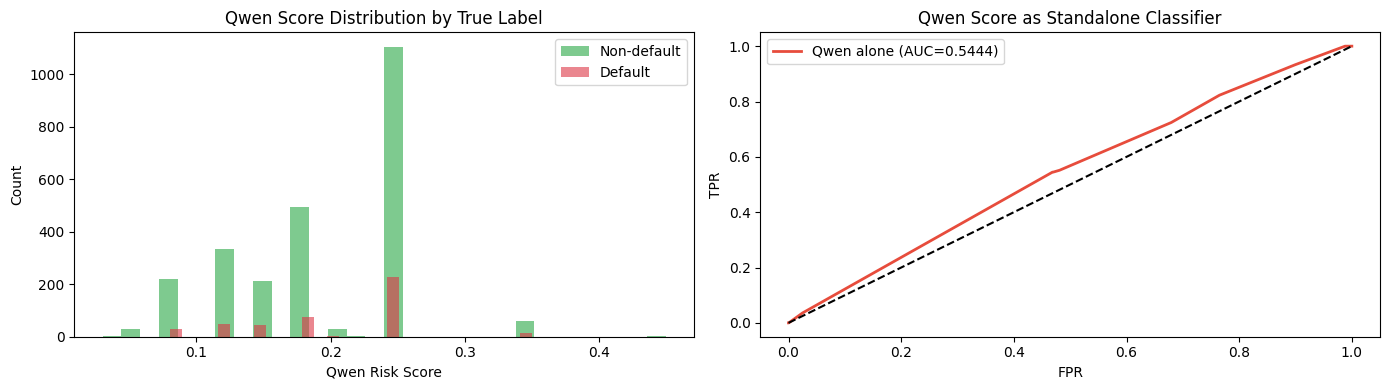

In [ ]:
# Qwen score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Filter valid (non-NaN) scores
mask_valid = df_sample['qwen_score'].notna()
print(f'Valid qwen scores: {mask_valid.sum()} / {len(df_sample)}')
df_valid = df_sample[mask_valid]

ax = axes[0]
for label, grp in df_valid.groupby(TARGET_COL):
    ax.hist(grp['qwen_score'], bins=30, alpha=0.6,
            label='Default' if label == 1 else 'Non-default',
            color='#DC3545' if label == 1 else '#28A745')
ax.set_xlabel('Qwen Risk Score')
ax.set_ylabel('Count')
ax.set_title('Qwen Score Distribution by True Label')
ax.legend()

ax = axes[1]
from sklearn.metrics import roc_curve as _rc
fpr_q, tpr_q, _ = _rc(df_valid[TARGET_COL], df_valid['qwen_score'])
auc_q = roc_auc_score(df_valid[TARGET_COL], df_valid['qwen_score'])
ax.plot(fpr_q, tpr_q, color=COLORS['qwen'], linewidth=2, label=f'Qwen alone (AUC={auc_q:.4f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Qwen Score as Standalone Classifier')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/figures/part2_qwen_distribution.png', dpi=150)
plt.show()

## 6. Pipeline C — ML + Qwen Feature

In [ ]:
# Align qwen_score with train/test split
df_train_c = df_sample.iloc[df_train.index] if hasattr(df_train, 'index') else df_train
# Rebuild splits with qwen_score column
df_sample_with_qwen = df_sample.copy()
df_train_c = df_sample_with_qwen.iloc[:int(0.8 * len(df_sample_with_qwen))]
df_test_c  = df_sample_with_qwen.iloc[int(0.8 * len(df_sample_with_qwen)):]

# Use the same split as before (reindex from df_train/df_test)
train_qwen = df_sample.loc[df_train.index, 'qwen_score'].values
test_qwen  = df_sample.loc[df_test.index,  'qwen_score'].values

X_train_c = X_train.copy().reset_index(drop=True)
X_train_c['qwen_score'] = train_qwen
X_test_c  = X_test.copy().reset_index(drop=True)
X_test_c['qwen_score']  = test_qwen

xgb_c = xgb.XGBClassifier(**XGB_KWARGS)
xgb_c.fit(X_train_c, y_train, eval_set=[(X_test_c, y_test)], verbose=False)
prob_c = xgb_c.predict_proba(X_test_c)[:, 1]
metrics_c = evaluate_full(y_test, prob_c, name='C: + Qwen3-Max (3K)')
print(f'Pipeline C: AUC={metrics_c["AUC"]} | KS={metrics_c["KS"]} | BACC={metrics_c["BACC"]}')

Pipeline C: AUC=0.6373 | KS=0.2859 | BACC=0.6429


## 7. Results — Table 2: Model Comparison on 3K Sample

In [ ]:
results_3k = pd.DataFrame([metrics_a, metrics_b, metrics_c]).set_index('Model')

print('=== TABLE 2: LLM Strength Comparison (3K Sample) ===')
print(results_3k[['AUC', 'KS', 'Gini', 'BACC', 'F1', 'Precision', 'Recall']].to_string())

results_3k.to_csv(f'{MODEL_DIR}/part2_table2_qwen_results.csv')
print('\nSaved to Drive.')

=== TABLE 2: LLM Strength Comparison (3K Sample) ===
                          AUC      KS    Gini    BACC      F1  Precision  Recall
Model                                                                           
A': Traditional (3K)   0.6487  0.2355  0.2975  0.6178  0.3333     0.2345  0.5761
B': + Naive BERT (3K)  0.6599  0.2767  0.3198  0.6384  0.3616     0.2737  0.5326
C: + Qwen3-Max (3K)    0.6373  0.2859  0.2746  0.6429  0.3590     0.2545  0.6087

Saved to Drive.


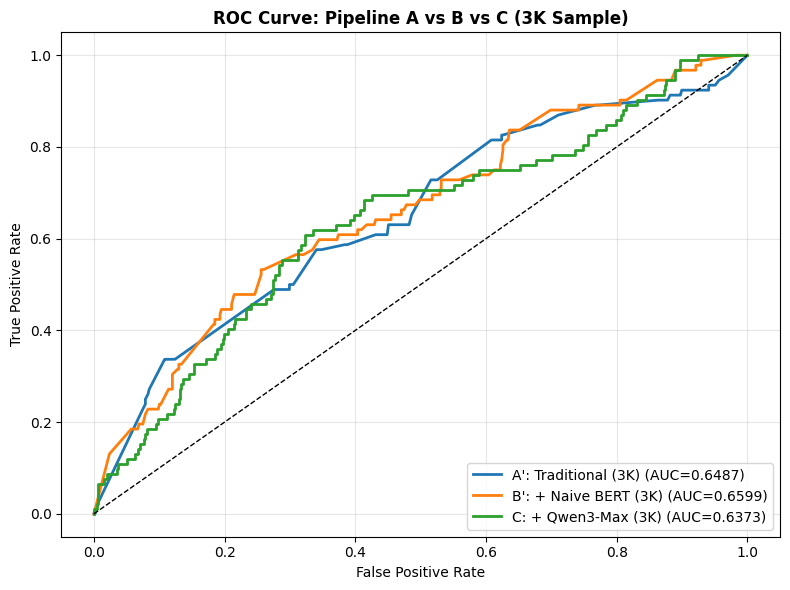

In [ ]:
# ROC comparison: all three pipelines
fig, ax = plt.subplots(figsize=(8, 6))
for prob, m, color in [
    (prob_a, metrics_a, COLORS['neutral']),
    (prob_b, metrics_b, COLORS['bert']),
    (prob_c, metrics_c, COLORS['qwen']),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2,
            label=f"{m['Model']} (AUC={m['AUC']:.4f})")

ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Pipeline A vs B vs C (3K Sample)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/figures/part2_roc_comparison.png', dpi=150)
plt.show()

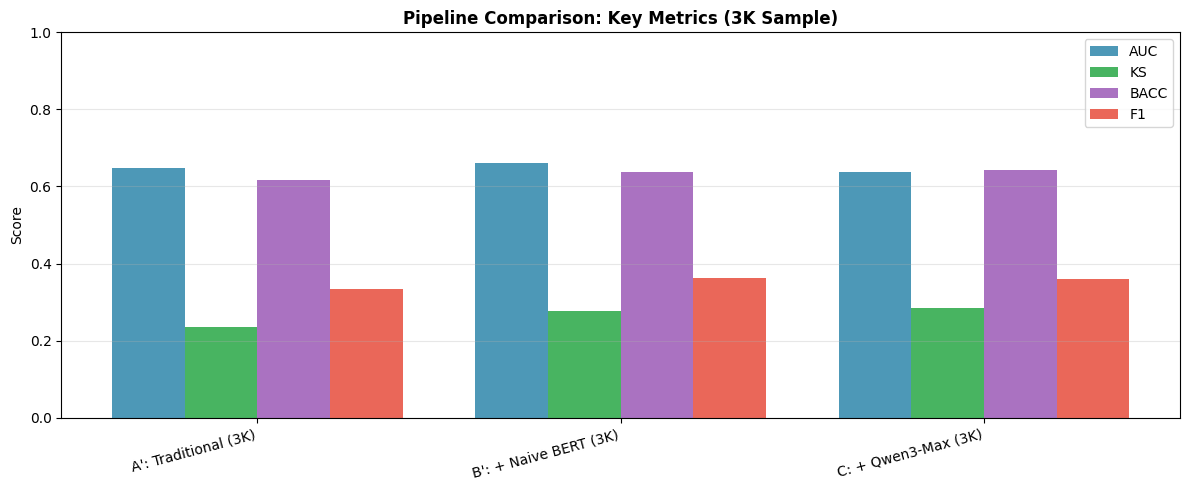

In [ ]:
# Bar chart of key metrics
metrics_plot = results_3k[['AUC', 'KS', 'BACC', 'F1']].reset_index()
metrics_melt = metrics_plot.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_plot))
w = 0.2
metric_colors = ['#2E86AB', '#28A745', '#9B59B6', '#E74C3C']
for i, metric in enumerate(['AUC', 'KS', 'BACC', 'F1']):
    vals = metrics_plot[metric].values
    ax.bar(x + i*w, vals, w, label=metric, color=metric_colors[i], alpha=0.85)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(metrics_plot['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Pipeline Comparison: Key Metrics (3K Sample)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/figures/part2_metrics_comparison.png', dpi=150)
plt.show()

## 8. LLM Quality Evaluation

Three dimensions (Consistency and Bias require only the cache — no extra API calls):

| Dimension | What it measures | Source |
|-----------|-----------------|--------|
| **Consistency** | Score variance across 5 repeated runs | `consistency_cache.json` |
| **Faithfulness** | Does reasoning direction match the score? | `qwen_cache_3000.json` |
| **Bias** | Does Qwen score correlate with actual default rate by group? | `qwen_cache_3000.json` |


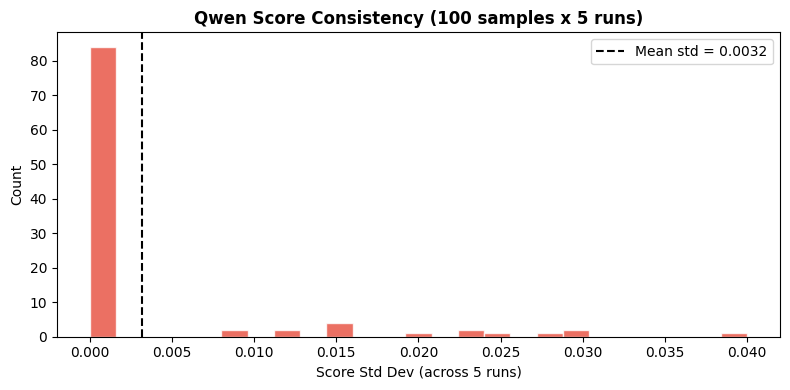

Mean std:   0.0032
Median std: 0.0000
Samples with std < 0.05: 100.0%
Samples with std < 0.10: 100.0%


In [ ]:
# 8.1 Consistency
CONSISTENCY_CACHE_PATH = f'{MODEL_DIR}/consistency_cache.json'

if not os.path.exists(CONSISTENCY_CACHE_PATH):
    print('consistency_cache.json not found. Re-run scripts/run_qwen_3000.py without --no-consistency.')
else:
    with open(CONSISTENCY_CACHE_PATH) as f:
        consist_cache = json.load(f)

    consist_stds = []
    for idx, scores in consist_cache.items():
        valid_scores = [s for s in scores if s == s]
        if len(valid_scores) >= 2:
            consist_stds.append(np.std(valid_scores))
    consist_stds = np.array(consist_stds)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(consist_stds, bins=25, color=COLORS['qwen'], alpha=0.8, edgecolor='white')
    ax.axvline(consist_stds.mean(), color='black', linestyle='--',
               label=f'Mean std = {consist_stds.mean():.4f}')
    ax.set_xlabel('Score Std Dev (across 5 runs)')
    ax.set_ylabel('Count')
    ax.set_title('Qwen Score Consistency (100 samples x 5 runs)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{DRIVE_DIR}/figures/part2_consistency.png', dpi=150)
    plt.show()

    print(f'Mean std:   {consist_stds.mean():.4f}')
    print(f'Median std: {np.median(consist_stds):.4f}')
    print(f'Samples with std < 0.05: {(consist_stds < 0.05).mean()*100:.1f}%')
    print(f'Samples with std < 0.10: {(consist_stds < 0.10).mean()*100:.1f}%')


In [ ]:
# 8.2 Faithfulness (Direction Check)
# High-score entries should mention risk language; low-score entries should mention protective language.
RISK_KEYWORDS    = ['debt', 'unemployed', 'struggling', 'behind', 'overdue',
                    'missed', 'late', 'medical', 'emergency', 'hospital']
PROTECT_KEYWORDS = ['employed', 'stable', 'years', 'business', 'invest',
                    'income', 'savings', 'credit', 'responsible', 'reliable']
HIGH_THRESHOLD = 0.30
LOW_THRESHOLD  = 0.15

faithful_count = 0
unfaithful_examples = []
total_checked = 0

for idx_str, entry in qwen_cache.items():
    if entry.get('parse_error', True):
        continue
    score = entry.get('score', float('nan'))
    reasoning = entry.get('reasoning', '').lower()
    if score != score or not reasoning:
        continue
    risk_hits    = sum(1 for kw in RISK_KEYWORDS    if kw in reasoning)
    protect_hits = sum(1 for kw in PROTECT_KEYWORDS if kw in reasoning)
    if score >= HIGH_THRESHOLD:
        faithful = risk_hits >= protect_hits
        total_checked += 1
    elif score <= LOW_THRESHOLD:
        faithful = protect_hits >= risk_hits
        total_checked += 1
    else:
        continue
    if faithful:
        faithful_count += 1
    elif len(unfaithful_examples) < 3:
        unfaithful_examples.append({'score': score, 'reasoning': reasoning[:200]})

faithfulness_rate = faithful_count / total_checked if total_checked > 0 else 0
print(f'Faithfulness: {faithful_count}/{total_checked} = {faithfulness_rate*100:.1f}%')
print('\nUnfaithful examples:')
for ex in unfaithful_examples:
    print(f"  score={ex['score']:.3f}: {ex['reasoning'][:120]}")


Faithfulness: 878/996 = 88.2%

Unfaithful examples:
  score=0.120: the borrower demonstrates motivation to reduce debt through consolidation, which is a protective factor. however, the ab
  score=0.350: the borrower is seeking to consolidate significant credit card debt across multiple lenders, totaling approximately $12,
  score=0.150: the loan is for a daughter's wedding, which is a non-essential but personally meaningful expense that may motivate timel


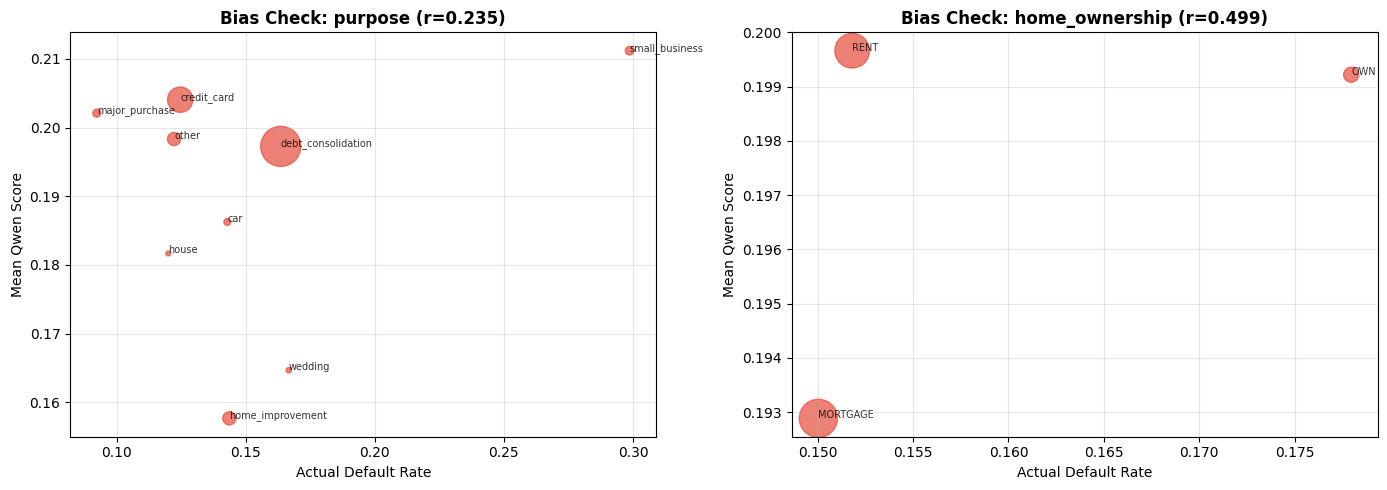

In [ ]:
# 8.3 Bias Analysis (Group-level)
# Positive correlation = Qwen score aligns with actual default rate (no systematic bias).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group_col in zip(axes, ['purpose', 'home_ownership']):
    if group_col not in df_sample.columns:
        ax.set_visible(False)
        continue
    grp = df_sample.groupby(group_col).agg(
        actual_default_rate=(TARGET_COL, 'mean'),
        mean_qwen_score=('qwen_score', 'mean'),
        count=(TARGET_COL, 'count')
    ).reset_index()
    grp = grp[grp['count'] >= 20]
    ax.scatter(grp['actual_default_rate'], grp['mean_qwen_score'],
               s=grp['count'] / 2, alpha=0.7, color=COLORS['qwen'])
    for _, row in grp.iterrows():
        ax.annotate(row[group_col], (row['actual_default_rate'], row['mean_qwen_score']),
                    fontsize=7, alpha=0.8)
    corr = grp[['actual_default_rate', 'mean_qwen_score']].corr().iloc[0, 1]
    ax.set_xlabel('Actual Default Rate')
    ax.set_ylabel('Mean Qwen Score')
    ax.set_title(f'Bias Check: {group_col} (r={corr:.3f})', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/figures/part2_bias.png', dpi=150)
plt.show()
